In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_8_natural = get_prompt("natural", 8)

prompt_8_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the 300K simulation.'

In [3]:
llm_model = "gpt-4-turbo-2024-04-09"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_8_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: The task involves multiple steps including simulation, structural analysis, and computation of specific properties for the protein 1LYZ. First, I need to download the PDB structure of 1LYZ to proceed with the simulation and subsequent analyses.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": {
    "query": "1LYZ"
  }
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_165223
Thought:

Now that I have the PDB file for 1LYZ, the next step is to set up and run the molecular dynamics simulations at two different temperatures, 300K and 400K. I will use the SetUpandRunFunction tool to perform these simulations. The simulations will be run for 1 picosecond each as requested.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_165223",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance

To proceed with the simulation at 300K, I need to correct the system parameters by specifying the constraintTolerance since rigidWater is set to True. I will adjust the system parameters and rerun the simulation for 1LYZ at 300K.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_165223",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "solvate": true,
      "constraintTolerance": "0.00001"
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance: 0.0005 
Building 

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_165223', 'forcefield_files': ['amber14-all.xml', 'amber14/tip3p.xml'], 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'solvate': True, 'constraintTolerance': '0.00001'}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * k

...

SASA plot saved to FIG_sasa_sim0_165258_20251223_174610.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_sim0_165258. SASA analysis completed. Saved the plot with plot ID fig0_174610. 
Thought:

The Solvent Accessible Surface Area (SASA) for the 300K simulation of protein 1LYZ has been successfully computed. Now, I will proceed to compute the radius of gyration for the same simulation.

Action:
```json
{
  "action": "RadiusofGyrationTool",
  "action_input": {
    "traj_file": "rec0_165303",
    "top_file": "top_sim0_165258"
  }
}
```


plot_name:  FIG_rgy_rec0_165303_20251223_174615.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_38/figures/FIG_rgy_rec0_165303_20251223_174615.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_38/figures/radii_of_gyration_rec0_165303.csv with id rgy_rec0_165303.Plot saved as: FIG_rgy_rec0_165303_20251223_174615.png with plot ID fig0_174615Average radius of gyration: 3.45 nm
Thought:

Final Answer: The molecular dynamics simulations for protein 1LYZ at 300K and 400K were successfully completed. The secondary structure analysis for the 300K simulation revealed 15,974 residues in helices, 3,686 residues in strands, 19,040 residues in coils, and a large number of unassigned residues, suggesting a potential error in the analysis or an issue with the input data.

Active sites for 1LYZ were identified at residues 53 and 71, with evidence codes from PROSITE-ProRule. No known binding sites or other relevant sites were found.

The RMSD for the 300K simulation was calculated and results were saved. The Solvent Accessible Surface Area (SASA) and the radius of gyration were also computed for the 300K simulation, with the average radius of gyration being 3.45 nm. These analyses provide a comprehensive understanding of the structural dynamics and properties of 1LYZ under the simulated conditions.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist,

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_165223: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_165223
 1LYZ_165247: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_165258: Initial positions for simulation sim0_165258
 sim0_165258: Basic Simulation of Protein 1LYZ_165247
 rec0_165303: Simulation trajectory for protein 1LYZ_165247 and simulation sim0_165258
 rec1_165303: Simulation state log for protein 1LYZ_165247 and simulation sim0_165258
 rec2_165303: Simulation pdb frames for protein 1LYZ_165247 and simulation sim0_165258
 top_sim0_170544: Initial positions for simulation sim0_170544
 sim0_170544: Basic Simulation of Protein 1LYZ_165247
 rec0_170550: Simulation trajectory for protein 1LYZ_165247 and simulation sim0_170544
 rec1_170550: Simulation state log for protein 1LYZ_165247 and simulation sim0_170544
 rec2_170550: Simulation pdb frames for protein 1LYZ_1652

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_165223"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_165223", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_165303")
top_path_1 = registry.get_mapped_path("top_sim0_165258")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

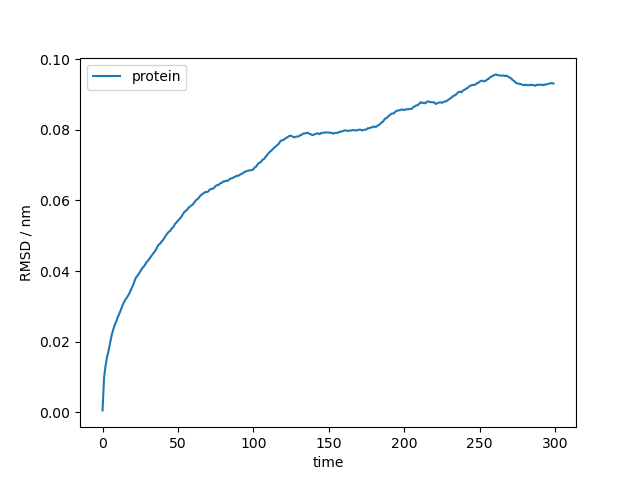

In [8]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_172135'))

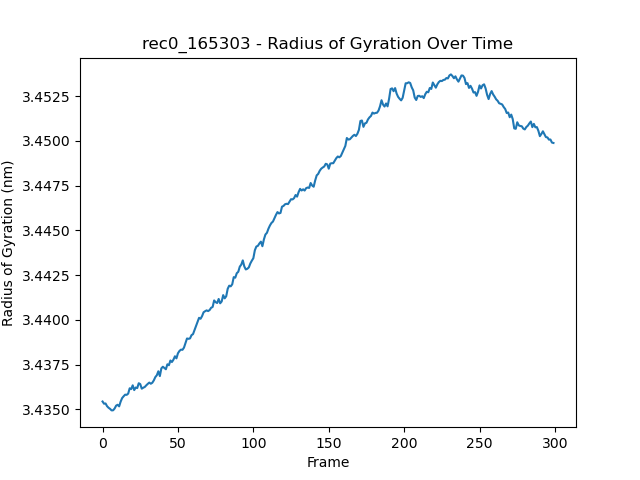

In [9]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_174615'))

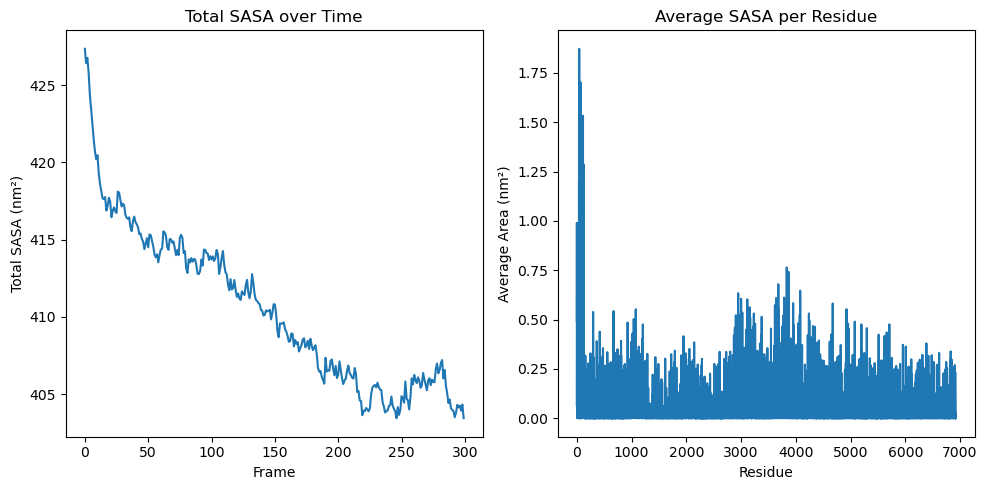

In [10]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_174610'))

In [7]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_170550")
top_path_2 = registry.get_mapped_path("top_sim0_170544")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

In [15]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 112076
Output tokens: 2386
LLM costs: $ 1.19234
